In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# --- Setup (move to a shared setup cell once you have one) ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'axes.spines.bottom': False,
})

In [2]:
# HELPER FUNCTION FOR FIG 1
def draw_population_inset(ax, per_cd, borough_info, borough_order):
    """Draw the borough-stacked population bar plot onto the given axes."""
    bar_height = 0.7
    for i, bcode in enumerate(borough_order):
        name, color = borough_info[bcode]
        cds = (per_cd[per_cd['borough_code'] == bcode]
               .sort_values('total_population', ascending=False))
        left = 0
        for _, row in cds.iterrows():
            ax.barh(
                i, row['total_population'],
                left=left, height=bar_height,
                color=color, edgecolor='white', linewidth=1.2,
            )
            left += row['total_population']
        # Borough total label
        ax.text(
            left + 50_000, i,
            f'{left / 1_000_000:.2f}M',
            va='center', ha='left',
            fontsize=9, color='#333333',
        )

    ax.set_yticks(range(len(borough_order)))
    ax.set_yticklabels(
        [borough_info[b][0] for b in borough_order],
        fontsize=10,
    )
    ax.invert_yaxis()

    ax.set_xlim(0, 3_000_000)
    ax.set_xticks([0, 1_000_000, 2_000_000, 3_000_000])
    ax.set_xticklabels(['0', '1M', '2M', '3M'], fontsize=8, color='#666666')
    ax.set_xlabel('population', fontsize=10, color='#666666')
    ax.tick_params(axis='x', length=6, color='#000000')
    ax.tick_params(axis='y', length=0)

    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color('#000000')
    ax.spines['bottom'].set_linewidth(1)

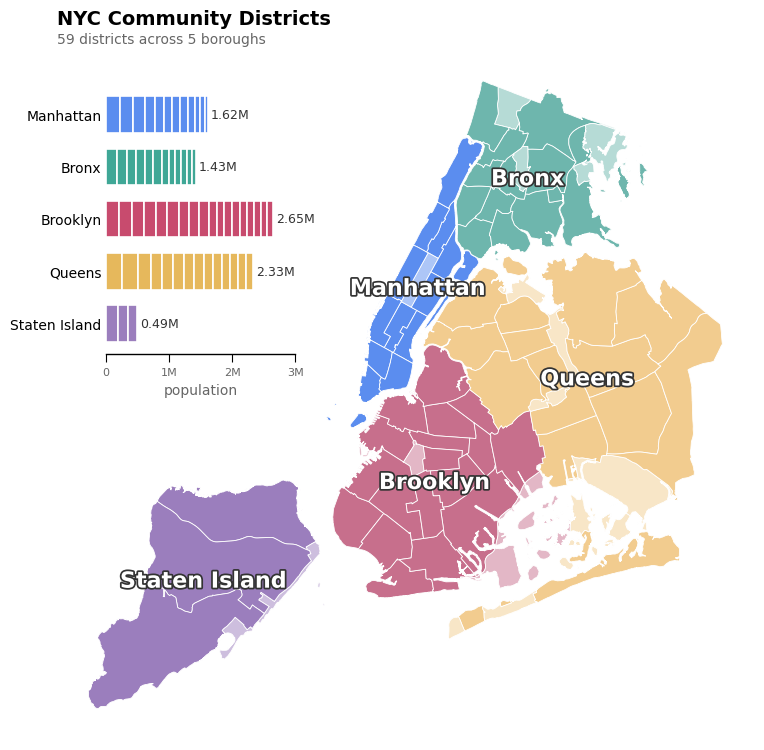

In [3]:
# ============================================================
# Figure 1: NYC Community Districts map by borough, with inset
# ============================================================

# ------------------------------------------------------------
# Data for inset
# ------------------------------------------------------------
df = pd.read_parquet('data/final/analytical_table.parquet')
per_cd = (df
          .drop_duplicates(subset='borocd')
          [['borocd', 'total_population']]
          .copy())

# Exclude JIAs
per_cd = per_cd[(per_cd['borocd'] % 100) < 20].copy()
per_cd['borough_code'] = per_cd['borocd'] // 100

# Borough metadata, matching the map
borough_info = {
    1: ('Manhattan',     '#5B8DEF'),
    2: ('Bronx',         '#3FA796'),
    3: ('Brooklyn',      '#C84B6E'),
    4: ('Queens',        '#E6B85C'),
    5: ('Staten Island', '#9B7EBD'),
}
borough_order = [1, 2, 3, 4, 5]  # MN → BX → BK → QN → SI, top to bottom

# ------------------------------------------------------------
# Data for map
# ------------------------------------------------------------
cb = gpd.read_file('data/raw/community_districts.geojson')
cb = cb.rename(columns={'boro_cd': 'borocd'}).astype({'borocd': 'int64'})
cb['is_jia'] = (cb['borocd'] % 100) >= 20
cb['borough_code'] = cb['borocd'] // 100
cb = cb.to_crs('EPSG:2263')  # for accurate visual proportions

# Borough color mapping
borough_colors = {
    # Okabe Ito palette ---
    #1: '#009E73',  # Manhattan
    #2: '#0072B2',  # Bronx
    #3: '#CC79A7',  # Brooklyn
    #4: '#D55E00',  # Queens
    #5: '#E69F00',  # Staten Island
    # Custom palette ---
    1: '#5B8DEF',  # Manhattan
    2: "#6EB6AD",  # Bronx
    3: "#C76F8C",  # Brooklyn
    4: '#F2CC8F',  # Queens
    5: '#9B7EBD',  # Staten Island
}
borough_names = {1: 'Manhattan', 2: 'Bronx', 3: 'Brooklyn', 4: 'Queens', 5: 'Staten Island'}

cb['color'] = cb['borough_code'].map(borough_colors)
# Lighten/desaturate JIAs by blending with white
def lighten(hex_color, amount=0.5):
    """Blend hex_color toward white by `amount` (0=no change, 1=white)."""
    import matplotlib.colors as mc
    rgb = mc.to_rgb(hex_color)
    lightened = tuple(c + (1 - c) * amount for c in rgb)
    hex = mc.to_hex(lightened)
    return hex

cb.loc[cb['is_jia'], 'color'] = cb.loc[cb['is_jia'], 'color'].apply(lighten)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 9))

cb.plot(
    color=cb['color'],
    edgecolor='white',
    linewidth=0.6,
    ax=ax,
)

# Borough labels — place at the centroid of each borough's CDs
for borough_code, name in borough_names.items():
    borough_cds = cb[(cb['borough_code'] == borough_code) & (~cb['is_jia'])]
    if len(borough_cds) == 0:
        continue
    # Use the unary union centroid for a stable label point
    centroid = borough_cds.geometry.union_all().centroid
    txt = ax.text(
        centroid.x, centroid.y, name,
        ha='center', va='center',
        fontsize=16, fontweight='bold',
        color='white',
    )
    # White text with subtle dark outline for legibility on any background
    txt.set_path_effects([
        pe.Stroke(linewidth=2.5, foreground='#333333'),
        pe.Normal()
    ])

ax.set_axis_off()
ax.set_title(
    'NYC Community Districts',
    loc='left', pad=18,
)
# Subtitle
ax.text(0.0, 1.005,
        '59 districts across 5 boroughs',
        transform=ax.transAxes,
        ha='left', va='bottom',
        fontsize=10, color='#666666')

# --- Add the inset axes ---
# Coordinates are [left, bottom, width, height] in figure-relative units (0-1).
inset_ax = fig.add_axes([0.18, 0.54, 0.21, 0.30])
draw_population_inset(inset_ax, per_cd, borough_info, borough_order)

#plt.tight_layout()
fig.savefig('figures/fig1_cds.svg', bbox_inches='tight', facecolor='white')
fig.savefig('figures/fig1_cds.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

**Figure 1.** New York City's 59 community districts (CDs) provide the unit of analysis. CDs are NYC's official sub-borough planning units, with populations in the tens to hundreds of thousands and explicit civic representation. CDs are colored by borough and demarcated by white boundaries. Faded colors indicate the 12 Joint Interest Areas (parks, airports, and other non-residential zones with no permanent population) shown for context but excluded from all further analysis. *Source: NYC Department of City Planning.*

ADDED AFTER INSET WORK: "Despite varying widely in geographic area, community districts contain similar populations (most fall in the 130-200k range), making them well-matched units for comparing reporting rates."

/tmp/ipykernel_37653/2631935336.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


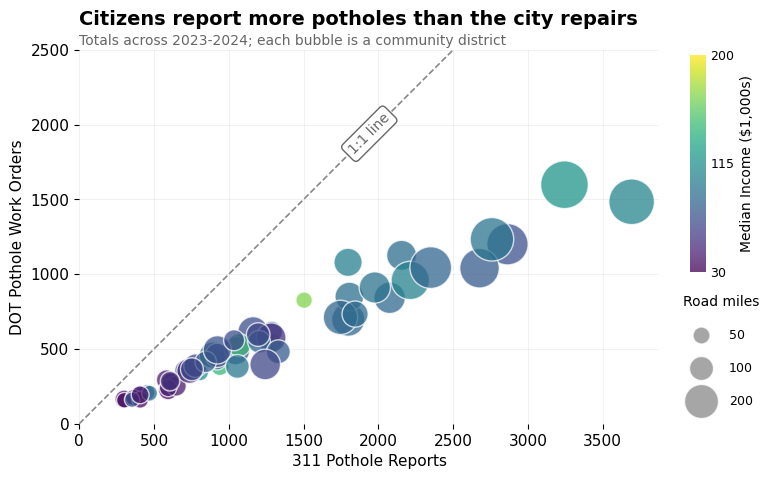

In [7]:
# ============================================================
# Figure 2: Citizen vs City Pothole Attention - raw numbers
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np

# --- Load and aggregate to per-CD totals ---
df = pd.read_parquet('data/final/analytical_table.parquet')

per_cd = (df
          .groupby('borocd')
          .agg(
              total_311=('n_reports_311', 'sum'),
              total_dot=('n_repairs_dot', 'sum'),
              median_income=('median_household_income', 'first'),
              road_miles=('road_miles', 'first'),
          )
          .reset_index())

# Exclude JIAs (consistent with the modeling table)
per_cd = per_cd[(per_cd['borocd'] % 100) < 20].copy()

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 7))

# 1:1 reference line — drawn first so points sit on top
lim = max(per_cd['total_311'].max(), per_cd['total_dot'].max()) * 1.05
ax.plot([0, lim], [0, lim], '--', color='#888888', linewidth=1.2, zorder=1)

# Scatter — color by income, size by road miles
scatter = ax.scatter(
    per_cd['total_311'],
    per_cd['total_dot'],
    c=per_cd['median_income'] / 1000,  # in thousands for readability
    s=per_cd['road_miles'] * 3,
    vmin=30, vmax=200,
    cmap='viridis',
    alpha=0.75,
    edgecolor='white',
    linewidth=1.0,
    zorder=2,
)

# 1:1 line label — placed along the line itself
ax.text(
    lim * 0.5, lim * 0.5,
    '1:1 line',
    rotation=45,
    rotation_mode='anchor',
    ha='center', va='center',
    fontsize=10, color='#666666',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#666666', alpha=1),
)

# Axis labels and title
ax.set_xlabel('311 Pothole Reports', fontsize=11)
ax.set_ylabel('DOT Pothole Work Orders', fontsize=11)
ax.set_title(
    'Citizens report more potholes than the city repairs',
    loc='left', pad=18, fontsize=14
)
# Subtitle
ax.text(0.0, 1.005,
        'Totals across 2023-2024; each bubble is a community district',
        transform=ax.transAxes,
        ha='left', va='bottom',
        fontsize=10, color='#666666')

# Axis limits, both starting at zero
ax.set_xlim(0, lim)
ax.set_ylim(0, 2500)
ax.set_aspect('equal')

# Light grid, no top/right spines
ax.grid(True, alpha=0.25, linestyle='-', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Colorbar — manually placed for precise control
# [left, bottom, width, height] in figure-relative coords (0-1)
cbar_ax = fig.add_axes([0.87, 0.45, 0.020, 0.31])
cbar = fig.colorbar(scatter, cax=cbar_ax)
# Set ticks to roughly min, mid, max of the actual data range
cbar.set_ticks([30, 115, 200])
cbar.set_ticklabels(['30', '115', '200'])
# More formatting
cbar.set_label('Median Income ($1,000s)', fontsize=10)
cbar.ax.tick_params(labelsize=9, length=0)
cbar.outline.set_visible(False)  # cleaner edge

# Size legend — invisible reference points that populate a legend
ref_road_miles = [50, 100, 200]
for rm in ref_road_miles:
    ax.scatter(
        [], [],  # empty data, nothing actually plotted
        s=rm * 3,  # same scaling factor as the main scatter
        c='#888888',
        alpha=0.75,
        edgecolor='white',
        linewidth=1.0,
        label=f'{rm}',
    )
ax.legend(
    title='Road miles',
    bbox_to_anchor=(1.2,0),
    loc='lower right',
    frameon=False,
    labelspacing=1.6,    # vertical room between bubble sizes
    borderpad=0.8,
    handletextpad=1.2,
    title_fontsize=10,
    fontsize=9,
)

plt.tight_layout()
fig.savefig('figures/fig2_scatter.svg', bbox_inches='tight', facecolor='white')
fig.savefig('figures/fig2_scatter.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

**Figure 2.** Total citizen pothole reports versus DOT work orders, one point per community district, summed over 2023–2024. Every district sits below the 1:1 line — citizens report 2–3 potholes for every one the city's work-order system records as repaired, a ratio consistent across the income, density, and road-network gradient. The question the project addresses is whether the *gap* between these two signals varies systematically by district, or whether they vary in lockstep with the underlying demographics that predict the absolute counts.

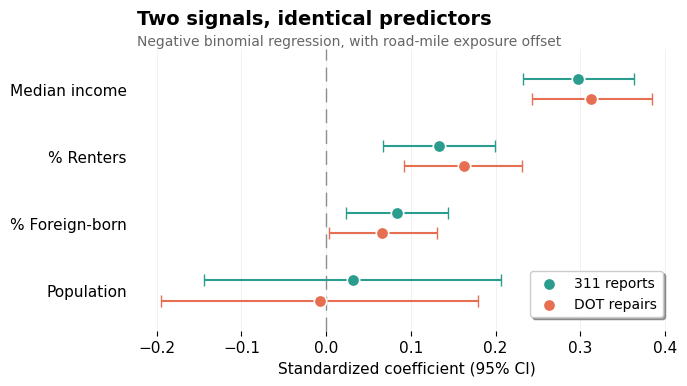

In [5]:
# ============================================================
# Figure 3: Predictors of Pothole Reporting
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt

# --- Load both coefficient tables ---
coef_311 = pd.read_csv('data/final/coefficients_311.csv', index_col=0)
coef_dot = pd.read_csv('data/final/coefficients_dot.csv', index_col=0)

# --- Prepare for plotting ---
# Drop intercept — uninterpretable when predictors are standardized
coef_311 = coef_311[coef_311['term'] != '(Intercept)'].copy()
coef_dot = coef_dot[coef_dot['term'] != '(Intercept)'].copy()

# Pretty-print the predictor names
term_labels = {
    'log(total_population)':    'Population',
    'median_household_income':  'Median income',
    'pct_renters':              '% Renters',
    'pct_foreign_born':         '% Foreign-born',
}
coef_311['label'] = coef_311['term'].map(term_labels)
coef_dot['label'] = coef_dot['term'].map(term_labels)

# Order from largest to smallest 311 effect (so plot reads top-down by importance)
order = (coef_311
         .sort_values('estimate', ascending=True)['label']
         .tolist())

coef_311['y'] = coef_311['label'].map({l: i for i, l in enumerate(order)})
coef_dot['y'] = coef_dot['label'].map({l: i for i, l in enumerate(order)})

# Offset the two models slightly so their dots don't overlap
OFFSET = 0.15
coef_311['y_plot'] = coef_311['y'] + OFFSET
coef_dot['y_plot'] = coef_dot['y'] - OFFSET

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 4))

# Reference line at zero — dashed, drawn first
ax.axvline(0, color='#888888',
           linestyle='--', linewidth=1.0,
           dashes=(10,5),
           zorder=1)

# Colors — distinct but harmonious
color_311 = '#2A9D8F'   # teal
color_dot = '#E76F51'   # warm coral

# 311 model: error bars first, then points
ax.errorbar(
    coef_311['estimate'], coef_311['y_plot'],
    xerr=[coef_311['estimate'] - coef_311['conf.low'],
          coef_311['conf.high'] - coef_311['estimate']],
    fmt='none', ecolor=color_311, elinewidth=1.5, capsize=4, zorder=2,
)
ax.scatter(
    coef_311['estimate'], coef_311['y_plot'],
    s=80, color=color_311, edgecolor='white', linewidth=1.2,
    label='311 reports', zorder=3,
)

# DOT model
ax.errorbar(
    coef_dot['estimate'], coef_dot['y_plot'],
    xerr=[coef_dot['estimate'] - coef_dot['conf.low'],
          coef_dot['conf.high'] - coef_dot['estimate']],
    fmt='none', ecolor=color_dot, elinewidth=1.5, capsize=4, zorder=2,
)
ax.scatter(
    coef_dot['estimate'], coef_dot['y_plot'],
    s=80, color=color_dot, edgecolor='white', linewidth=1.2,
    label='DOT repairs', zorder=3,
)

# Y axis: predictor labels
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.set_ylim(-0.6, len(order) - 0.4)

# X axis
ax.set_xlabel('Standardized coefficient (95% CI)', fontsize=11)

# Title
ax.set_title(
    'Two signals, identical predictors',
    loc='left', pad=18, fontsize=14
)
# Subtitle
ax.text(0.0, 1.005,
        'Negative binomial regression, with road-mile exposure offset',
        transform=ax.transAxes,
        ha='left', va='bottom',
        fontsize=10, color='#666666')

# Legend
ax.legend(
    loc='lower right',
    frameon=True,
    fontsize=10,
    borderaxespad=1.0,
    fancybox=True,
    shadow=True
)

# Clean up spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(left=False)
ax.grid(axis='x', alpha=0.25, linestyle='-', linewidth=0.5)

plt.tight_layout()
fig.savefig('figures/fig3_coefficients.svg', bbox_inches='tight', facecolor='white')
fig.savefig('figures/fig3_coefficients.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

**Figure 3.** Standardized coefficients from two parallel negative binomial regressions: one predicting citizen 311 reports per road-mile, one predicting DOT work orders per road-mile. Each predictor's confidence interval overlaps almost completely between the two outcomes, indicating that citizen reporting and city repair activity respond to demographics with statistically inistinguishable strength. Median household income and renter share are the strongest predictors of both signals; population (after adjusting for road-mile exposure) is not a meaningful predictor of either.

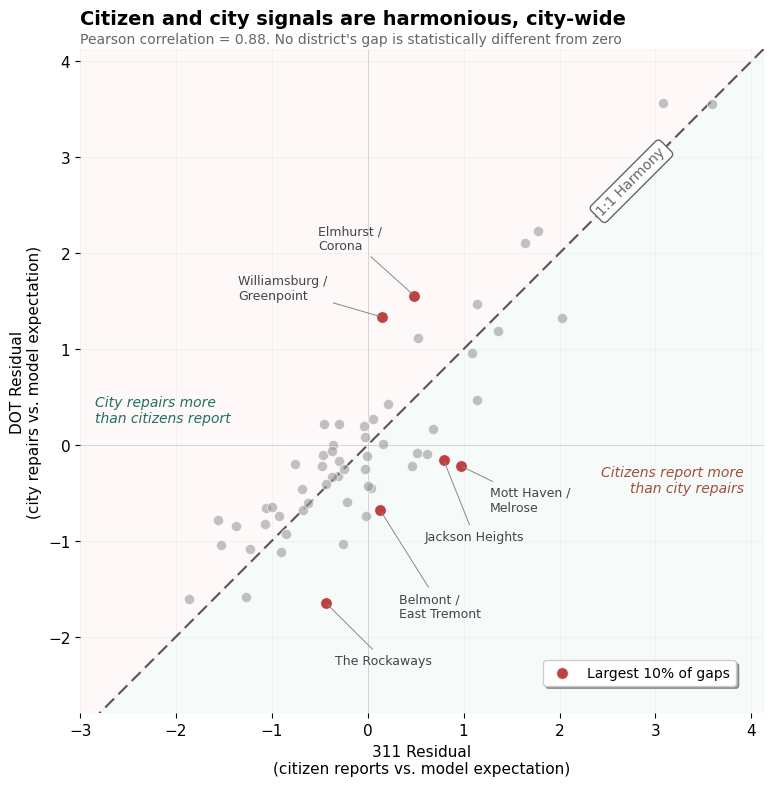

In [6]:
# ============================================================
# Figure 4: Where 311 and DOT Signals Diverge
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Load ---
df = pd.read_csv('data/final/model_preds_resids.csv', index_col=0)

# Make sure outliers are boolean (CSV may have written them as strings)
df['is_outlier'] = df['is_outlier'].astype(str).str.lower().isin(['true', '1'])

# Outlier neighborhood names — adjust to match your selected CDs
outlier_labels = {
    201: 'Mott Haven /\nMelrose',
    206: 'Belmont /\nEast Tremont',
    301: 'Williamsburg /\nGreenpoint',
    403: 'Jackson Heights',
    404: 'Elmhurst /\nCorona',
    414: 'The Rockaways',
}

# Hand-tuned label offsets (in data units) — tweak after first render
label_offsets = {
    201: (0.30, -0.35),
    206: (0.20, -1.00),
    301: (-1.5, 0.30),
    403: (-0.2, -0.80),
    404: (-1.00, 0.60),
    414: (0.1, -0.60),
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 8))

# Compute symmetric axis limits centered on zero, padded slightly
lim = max(df['resid_311'].abs().max(), df['resid_dot'].abs().max()) * 1.15

# Background: subtle shading above/below the diagonal to label the gap quadrants
xx = np.linspace(-lim, lim, 100)
ax.fill_between(xx, xx, lim, color='#E76F51', alpha=0.04, zorder=0)
ax.fill_between(xx, -lim, xx, color='#2A9D8F', alpha=0.04, zorder=0)

# Zero reference lines
ax.axhline(0, color='#CCCCCC', linewidth=0.5, zorder=1)
ax.axvline(0, color='#CCCCCC', linewidth=0.5, zorder=1)

# 1:1 diagonal — visually dominant
ax.plot([-lim, lim], [-lim, lim],
        '--', color='#555555', linewidth=1.5, dashes=(6,3), zorder=2)
ax.text(
    2.75, 2.75,
    '1:1 Harmony',
    rotation=45,
    rotation_mode='anchor',
    ha='center', va='center',
    fontsize=10, color='#666666',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#666666', alpha=1),
)

# Quadrant annotations — subtle, in the corners
ax.text(lim * 0.95, -lim * 0.05,
        'Citizens report more\nthan city repairs',
        ha='right', va='top',
        fontsize=10, color='#A0503A', style='italic', zorder=2)
ax.text(-3 * 0.95, lim * 0.05,
        'City repairs more\nthan citizens report',
        ha='left', va='bottom',
        fontsize=10, color='#1F6F65', style='italic', zorder=2)

# Points — non-outliers first
non_out = df[~df['is_outlier']]
out = df[df['is_outlier']]

ax.scatter(non_out['resid_311'], non_out['resid_dot'],
           s=55, color='#999999', alpha=0.6,
           edgecolor='white', linewidth=0.8, zorder=3)

ax.scatter(out['resid_311'], out['resid_dot'],
           s=80, color='#B22222', alpha=0.85,
           edgecolor='white', linewidth=1.2, zorder=4,
           label='Largest 10% of gaps')

# Outlier labels — hand-placed
for _, row in out.iterrows():
    code = int(row['borocd'])
    if code not in outlier_labels:
        continue
    dx, dy = label_offsets.get(code, (0.15, 0.15))
    ax.annotate(
        outlier_labels[code],
        xy=(row['resid_311'], row['resid_dot']),
        xytext=(row['resid_311'] + dx, row['resid_dot'] + dy),
        fontsize=9, color='#444444', ha='left', va='center',
        arrowprops=dict(
            arrowstyle='-', color='#888888', linewidth=0.7,
            connectionstyle='arc3,rad=0',
        ),
        zorder=5,
    )

# Legend for outlier labels
ax.legend(
    loc='lower right',
    frameon=True,
    fontsize=10,
    borderaxespad=2.0,
    fancybox=True,
    shadow=True
)

# Axes
ax.set_xlim(-3, lim)
ax.set_ylim(-2.8, lim)
ax.set_aspect('equal')
ax.set_xlabel('311 Residual\n(citizen reports vs. model expectation)', fontsize=11)
ax.set_ylabel('DOT Residual\n(city repairs vs. model expectation)', fontsize=11)

# Title and subtitle
correlation = df['resid_311'].corr(df['resid_dot'])
ax.set_title('Citizen and city signals are harmonious, city-wide',
             loc='left', pad=18, fontsize=14, fontweight='bold')
ax.text(0.0, 1.005,
        f'Pearson correlation = {correlation:.2f}. No district\'s gap is statistically different from zero',
        transform=ax.transAxes,
        ha='left', va='bottom',
        fontsize=10, color='#666666')

# Spines and grid
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2, linestyle='-', linewidth=0.4)

plt.tight_layout()
fig.savefig('figures/fig4_residuals.svg', bbox_inches='tight', facecolor='white')
fig.savefig('figures/fig4_residuals.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

**Figure 4.** Pearson residuals from the two negative binomial models, one point per community district. Distance from the dashed diagonal indicates where the two signals diverge — points above the line are districts where DOT activity exceeded model expectations more than 311 reports did, and vice versa. Six districts (highlighted) sit visibly off the diagonal, but the residual correlation is high (r = 0.88) and none of the per-district gaps are statistically distinguishable from zero after correction for multiple comparisons. The finding: citizen and city pothole attention in NYC are remarkably concordant once demographics and road exposure are accounted for.